# Guia 3
## a)
Escribir una función en Python que simule la distribución posterior 𝑝(𝜃 |𝑦) para un modelo
binomial con prior Beta(𝛼, 𝛽). La función debe tener como input los hiperparámetros del
prior (𝛼 y 𝛽), los datos observados (el número total de ensayos 𝑛 y la cantidad de éxitos 𝑦) y
la cantidad de samples de la posterior que quiero que devuelva.

 


In [11]:
from scipy.stats import beta

# Funcion que simule 𝑝(𝜃 |𝑦)
def posterior_binomial(alpha: int, betha: int, n: int, y: int, samples_to_return: int)-> list: 
    """ 
    Toma como parametros los hiperparametros del prior 
    (𝛼, 𝛽) y los datos observados
    (n=total ensayos, y = cant exitos)
    """
    posterior = beta(alpha + y, betha + n - y)
    return posterior.rvs(samples_to_return)



 Un estudio reporta que de 100 pacientes tratados con un nuevo medicamento, 70 mostraron
mejoría. Calcular la distribución posterior de la probabilidad de mejoría 𝜃 después de este
estudio. Utilizar diferentes priors y comparar las distribuciones posteriores resultantes después de observar el mismo estudio. Graficar las distribuciones posteriores para visualizar
la influencia del prior en la inferencia bayesiana sobre 𝜃. ¿Qué sucede cuando se varía la
esperanza del prior? ¿Qué sucede cuando se varía 𝛼 + 𝛽 manteniendo constante la esperanza
del prior?

In [14]:
pacientes = 100
pacientes_mejoria = 70

lista_priors_alpha_beta = [(1, 1), (10, 7), (100, 70), (200, 140), (400, 280), (1000, 700)]
samples_deseados = 100

Promedio de priors 0.5882352941176471


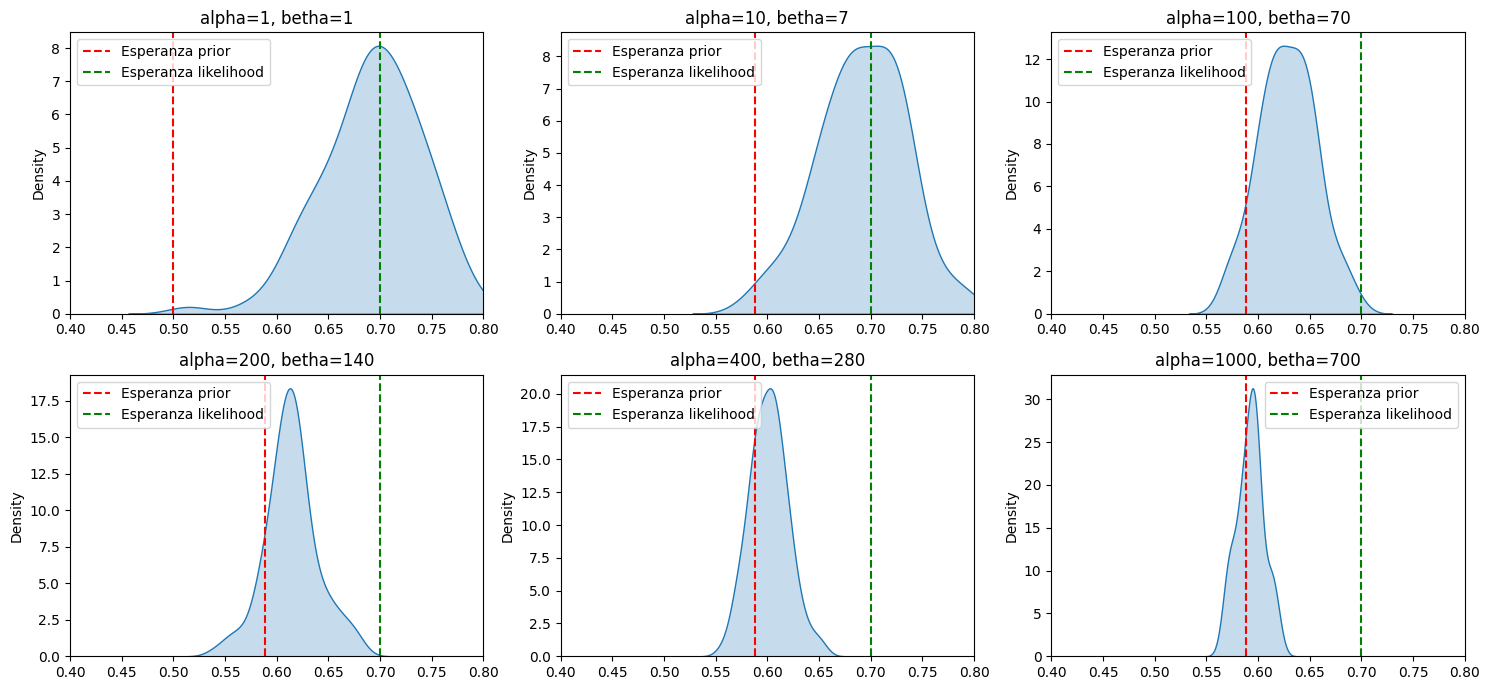

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 3, figsize=(15, 7))


# Calculo la esperanza de la likelihood para incluirla en el gráfico
esperanza_likelihood = mostraron_mejoria / pacientes_tratados
esperanzas_prior  = []

for i, (alpha, betha) in enumerate(lista_priors_alpha_beta):
    samples = posterior_binomial(alpha, betha, pacientes,pacientes_mejoria, samples_deseados)

    # Incluyo en cada gráfico la esperanza de cada prior
    esperanza_p = alpha / (alpha + betha)
    esperanzas_prior.append(esperanza_p)
    axs[i // 3, i % 3].axvline(esperanza_p, color='red', linestyle='--', label='Esperanza prior')
    
    # Incluyo en cada gráfico la esperanza de la likelihood
    axs[i // 3, i % 3].axvline(esperanza_likelihood, color='green', linestyle='--', label='Esperanza likelihood')

    # Gráficos para las posteriors
    sns.kdeplot(samples, ax=axs[i // 3, i % 3], fill=True)
    axs[i // 3, i % 3].set_title(f'alpha={alpha}, betha={betha}')
    axs[i // 3, i % 3].set_xlim(0.4, 0.8)
    axs[i // 3, i % 3].legend()

esperanzas_prior.pop(0)

print(f"Promedio de priors {sum(esperanzas_prior)/len(esperanzas_prior)}")
plt.tight_layout()
plt.show()

A partir de estos gráficos se pueden notar varias cosas:

Primero tenemos que la esperanza de la binomial propuesta por el enunciado es de 0.7, que es justo el pico que vemos en el primer gráfico a la izquierda cuando el prior es una Beta(1, 1), es decir: No informativo

Luego en el resto de gráficos consideramos una distribución Beta de esperanza apróximadamente 0.58, que luego al tomar valores de alpha y beta más grandes manteniendo la proporcionalidad con la esperanza se puede notar como cada vez más la posterior se acerca más a la esperanza del prior alejándose de la esperanza inicial de la likelihood

Luego si se varía la esperanza del prior, la posterior se acercará más o menos a la esperanza dada según los valores de alpha y beta sean más o menos alto

Solucion a y b dada por gpt


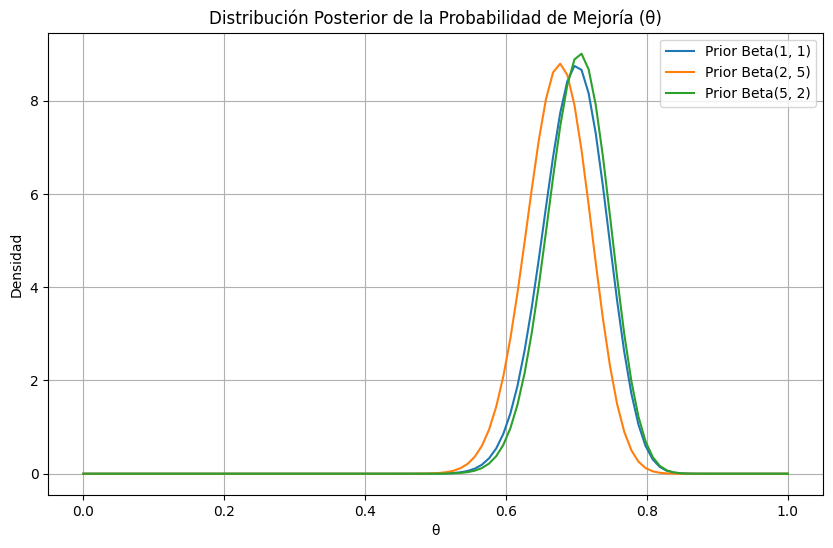

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Función para simular la distribución posterior
def posterior_binomial_beta(alpha, beta, n, y, num_samples):
    # Actualizamos los parámetros del prior Beta según los datos
    alpha_post = alpha + y
    beta_post = beta + n - y
    
    # Generamos muestras de la distribución Beta posterior
    samples = np.random.beta(alpha_post, beta_post, size=num_samples)
    
    return samples, alpha_post, beta_post

# Datos del estudio
n = 100  # número total de pacientes
y = 70   # número de pacientes que mejoraron

# Hiperparámetros de diferentes priors
priors = [(1, 1), (2, 5), (5, 2)]

# Número de muestras de la posterior
num_samples = 10000

# Graficar las distribuciones posteriores para diferentes priors
plt.figure(figsize=(10, 6))

for alpha_prior, beta_prior in priors:
    samples, alpha_post, beta_post = posterior_binomial_beta(alpha_prior, beta_prior, n, y, num_samples)
    x = np.linspace(0, 1, 100)
    plt.plot(x, beta.pdf(x, alpha_post, beta_post), label=f'Prior Beta({alpha_prior}, {beta_prior})')

plt.title('Distribución Posterior de la Probabilidad de Mejoría (θ)')
plt.xlabel('θ')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.show()


 Elegir alguno de los priors del item anterior y probar cómo cambia la distribución posterior
al variar la cantidad de pacientes tratados pero manteniendo constante la tasa de pacientes
que mostraron mejoría.

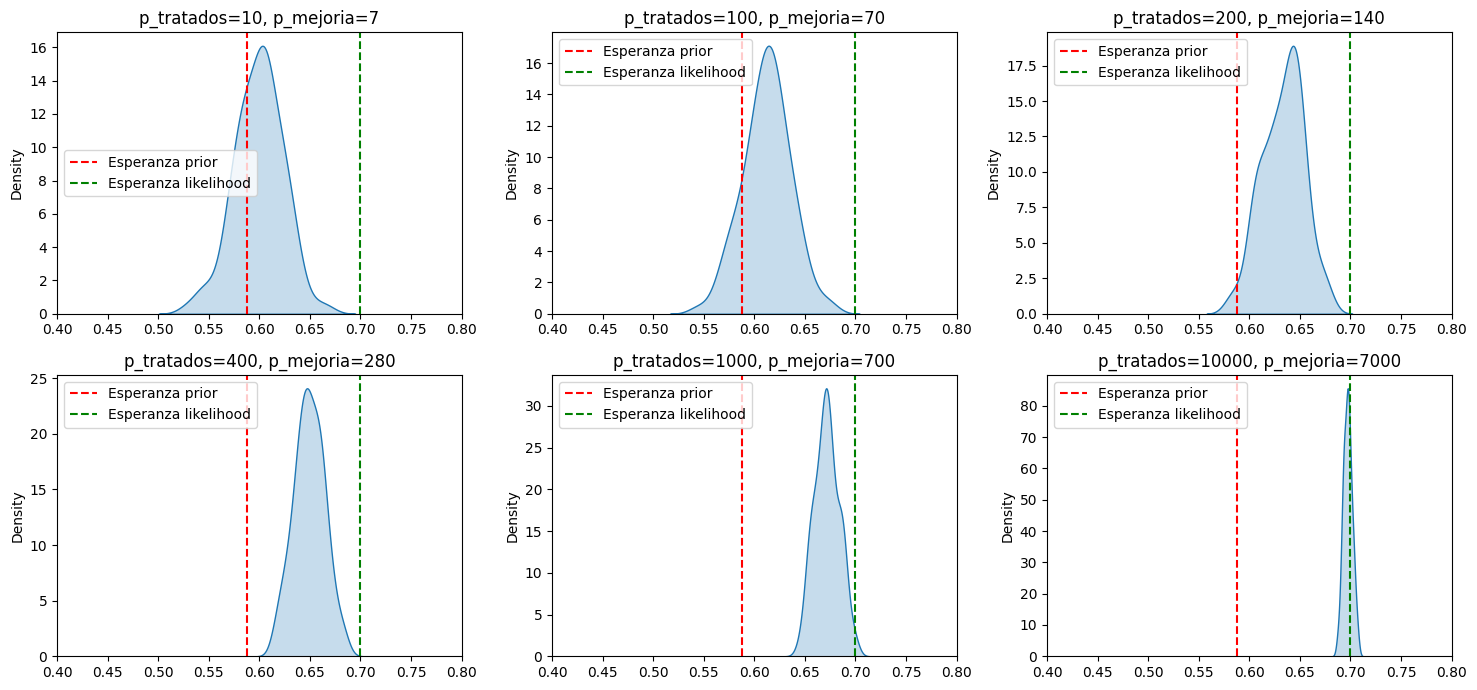

In [22]:
alpha_prior = 200
beta_prior = 140

fig, axs = plt.subplots(2, 3, figsize=(15, 7))

# Defino una lista de n y y
lista_n_y = [(10, 7), (100, 70), (200, 140), (400, 280), (1000, 700), (10000, 7000)]

# Calculo la esperanza del prior para incluirla en el gráfico
esperanza_prior = alpha_prior / (alpha_prior + beta_prior)
for i, (n, y) in enumerate(lista_n_y):
    samples = posterior_binomial(alpha_prior, beta_prior, n, y, samples_devolver)
    
    # Incluyo en cada gráfico la esperanza del prior
    axs[i // 3, i % 3].axvline(esperanza_prior, color='red', linestyle='--', label='Esperanza prior')
    
    # Incluyo en cada gráfico la esperanza de la likelihood
    axs[i // 3, i % 3].axvline(y/n, color='green', linestyle='--', label='Esperanza likelihood')

    # Gráficos para las posteriors
    sns.kdeplot(samples, ax=axs[i // 3, i % 3], fill=True)
    axs[i // 3, i % 3].set_title(f'p_tratados={n}, p_mejoria={y}')
    axs[i // 3, i % 3].set_xlim(0.4, 0.8)
    axs[i // 3, i % 3].legend()

plt.tight_layout()
plt.show()